In [18]:
# %cd /home/maia-user/NeuroCBIR/
%cd /cephyr/users/felixnie/Alvis/NeuroCBIR/
%matplotlib inline


/cephyr/users/felixnie/Alvis/NeuroCBIR


### Whole brain

In [2]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm import tqdm

def retrieve_topk_for_queries(
    dataset: pd.DataFrame,
    queries: pd.DataFrame,
    top_k: int = 3,
    feature_column: str = "features",
    guid_column: str = "GUID"
) -> pd.DataFrame:
    """
    Retrieve the top-k most similar entries for a subset of queries, 
    using cosine similarity against the full dataset as the retrieval pool.

    Args:
        dataset (pd.DataFrame): Full pool of entries with features and GUIDs.
        queries (pd.DataFrame): Subset of rows from dataset to use as queries.
        top_k (int): Number of top similar entries to retrieve.
        feature_column (str): Column containing the feature vectors.
        guid_column (str): Column with unique scan identifiers (e.g., 'GUID').

    Returns:
        pd.DataFrame: Retrieval results. One row per query, first column is the query GUID,
                      followed by the GUIDs of the top-k retrieved entries.
    """
    if top_k == -1:
        top_k = len(dataset) - 1  # Exclude self if present
    
    # Retrieval pool
    features_matrix = np.stack(dataset[feature_column].values)
    guids = dataset[guid_column].values

    # Queries
    query_features = np.stack(queries[feature_column].values)
    query_guids = queries[guid_column].values

    retrievals = []
    for i in tqdm(range(len(queries)), desc="Retrieving"):
        similarities = cosine_similarity(query_features[i].reshape(1, -1), features_matrix)[0].astype(np.float32)
        
        # Exclude self if query is in the dataset and same subject
        subject_mask = (dataset["subject"] == queries.iloc[i]["subject"]).values
        similarities[subject_mask] = -1  # Zero out similarities for same subject
        # if query_guids[i] in guids:
        #     idx_self = np.where(guids == query_guids[i])[0]
        #     similarities[idx_self] = -1

        # Get top-k
        top_k_indices = np.argsort(similarities)[::-1][:top_k]
        row = [query_guids[i]] + guids[top_k_indices].tolist() + similarities[top_k_indices].tolist()
        retrievals.append(row)

    col_names = ["query"] + [f"top{i+1}" for i in range(top_k)] + [f"sim{i+1}" for i in range(top_k)]
    return pd.DataFrame(retrievals, columns=col_names)

In [5]:
config = {
    # "data_path": "/home/maia-user/cifs/Datasets/",
    "data_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/",
    "metadata_file_name": "combined_metadata.csv",
    "emb_dir": "dev/data_private/results/whole_brain/eval__d_32__m_02__lid_02__mid_02__pn_005",
    "output_dir": "data/explanability",
    "embedding_file": "projected_embeddings.parquet",
    "class_column": "subject",
    "top_k_values": [
        -1
    ],
}

n_guids = 30

In [6]:
import os
import pandas as pd
import logging

# Load and filter metadata
clinical_ds = pd.read_csv(os.path.join(config["data_path"], config["metadata_file_name"]))

# filter out bad quality
clinical_ds = clinical_ds[clinical_ds["useable"] == 1].reset_index(drop=True)

# Load real features from parquet
emb_path = os.path.join(config["emb_dir"], config["embedding_file"])  # e.g., "outputs/embeddings.parquet"
df_embs = pd.read_parquet(emb_path)

# Ensure GUID is string and joinable
df_embs["GUID"] = df_embs["GUID"].astype(str)
clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

# Merge on GUID
dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

# Convert embedding columns into a single 'features' column of vectors
embedding_cols = [col for col in df_embs.columns if col != "GUID"]
dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)

# Pick random n_queries from dataset as queries
queries = dataset.sample(n=n_guids, random_state=42).reset_index(drop=True)
queries_guids = set(queries["GUID"].tolist())

# Select only n_rows randomly from the dataset
# Compute retrieval
retrieval_path = os.path.join(config["output_dir"], "retrieval_wb.csv")
logging.info("Computing retrieved cases...")
top_k_max = max(config["top_k_values"])
retrieval_df = retrieve_topk_for_queries(dataset, queries, top_k=top_k_max, 
                                         feature_column="features", 
                                         guid_column="GUID"
                                         )

logging.info("✓ Done: retrieved cases.")
# retrieval_df.to_csv(retrieval_path, index=False)
# logging.info(f"Saved retrievals to {retrieval_path}")

retrieval_wb = retrieval_df.copy()


Retrieving: 100%|██████████| 30/30 [00:00<00:00, 146.63it/s]


### Region brain

In [7]:
config = {
    # "data_path": "/home/maia-user/cifs/Datasets/",
    "data_path": "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/",
    "emb_dir": "dev/data_private/results/region_brain/eval__d_32__m_02__lid_02__mid_02__pn_005",
    "output_dir": "dev/data_private/explanability",
    "metadata_file_name": "combined_metadata.csv",
    "labels_path": "data/labels.csv",
    "bb_path": "data/bounding_boxes.csv",
    "embedding_file": "projected_embeddings.parquet",
    "project_filter": "",
    "class_column": "subject",
    "top_k_values": [
        top_k_max
    ],
    "struct_names": None, # <-- Set to None to compute all struct names
    # "struct_names": [ # <-- Set to None to compute all struct names
    #     "Left-Hippocampus",
    #     "Left-Thalamus",
    #     "Left-Amygdala",
    #     "Left-Lateral-Ventricle",
    #     "Right-Hippocampus",
    #     "Right-Thalamus",
    #     "Right-Amygdala",
    #     "Right-Lateral-Ventricle",
    # ]
}



In [8]:
# Load and filter metadata
clinical_ds = pd.read_csv(os.path.join(config["data_path"], config["metadata_file_name"]))

# Load real features from parquet
emb_path = os.path.join(config["emb_dir"], config["embedding_file"])  # e.g., "outputs/embeddings.parquet"
df_embs = pd.read_parquet(emb_path)


# Ensure GUID is string and joinable
df_embs["GUID"] = df_embs["GUID"].astype(str)
df_embs["LabelName"] = df_embs["LabelName"].astype(str)
clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

clinical_ds = clinical_ds[clinical_ds["useable"] == 1].reset_index(drop=True)

# Merge on GUID
dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

# Convert embedding columns into a single 'features' column of vectors
embedding_cols = [col for col in df_embs.columns if not col in  ["GUID", "LabelName"]]
dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)

all_metrics = {}
combined_retrievals = []

struct_names = config["struct_names"]
if struct_names is None:
    labels_df = pd.read_csv(config["labels_path"])
    valid_structs = labels_df[labels_df["Use"] == 1]["LabelName"].unique()
    struct_names = [s for s in dataset["LabelName"].unique() if s in valid_structs]
    # select 40 random structures for testing
    # struct_names = np.random.choice(struct_names, size=40, replace=False).tolist()

# Loading previuos computed structures in the .csv file
cr_struct_names = []
retrieval_path = os.path.join(config["output_dir"], "retrieval_rb_all.csv")
for struct_name in struct_names:
    if (struct_name in all_metrics) and (struct_name in cr_struct_names):
        print(f"Skipping. Struct already computed in .json file: {struct_name}")
        continue

    print(f"Processing: {struct_name}")

    # Subset dataset to current structure
    subset = dataset.query(f"LabelName == '{struct_name}'").reset_index(drop=True)
    
    # Pick random n_queries from previusly computed structure as queries
    queries = subset[subset["GUID"].isin(queries_guids)].reset_index(drop=True)
    
    # Select only n_rows randomly from the dataset
    # Compute retrieval
    logging.info("Computing retrieved cases...")
    top_k_max = max(config["top_k_values"])
    retrieval_df = retrieve_topk_for_queries(subset, queries, top_k=top_k_max, 
                                            feature_column="features", 
                                            guid_column="GUID"
                                            )
    
    # Add LabelName column for tracking
    retrieval_df["LabelName"] = struct_name
    combined_retrievals.append(retrieval_df)
    
# After the loop — save the combined retrievals
retrieval_rb = pd.concat(combined_retrievals, ignore_index=True)
# retrieval_rb.to_csv(retrieval_path, index=False)

print(f"✅ Evaluation complete. Results saved to: {config['output_dir']}")

    

Processing: Left-Cerebral-White-Matter


Retrieving: 100%|██████████| 30/30 [00:00<00:00, 154.62it/s]


Processing: Left-Lateral-Ventricle


Retrieving: 100%|██████████| 30/30 [00:00<00:00, 158.73it/s]


Processing: Left-Inf-Lat-Vent


...

Processing: ctx-rh-transversetemporal


Retrieving: 100%|██████████| 30/30 [00:00<00:00, 154.08it/s]


Processing: ctx-rh-insula


Retrieving: 100%|██████████| 30/30 [00:00<00:00, 161.28it/s]


✅ Evaluation complete. Results saved to: dev/data_private/explanability


In [9]:
# Short every row from retrieval_rb based on retrieval_wb
import pandas as pd

def reorder_rb_using_wb(retrieval_wb, retrieval_rb, max_k=1000):

    id_cols_wb = [c for c in retrieval_wb.columns if c.startswith("top")]
    id_cols_rb = [c for c in retrieval_rb.columns if c.startswith("top")]
    sim_cols_rb = [c for c in retrieval_rb.columns if c.startswith("sim")]

    reordered_rows = []

    for q in retrieval_wb["query"].unique():

        wb_row = retrieval_wb[retrieval_wb["query"] == q].iloc[0]
        wb_order = wb_row[id_cols_wb].tolist()

        rb_rows = retrieval_rb[retrieval_rb["query"] == q]

        for _, rb_row in rb_rows.iterrows():

            region = rb_row["LabelName"]

            rb_id_list = rb_row[id_cols_rb].tolist()
            rb_sim_list = rb_row[sim_cols_rb].tolist()
            rb_dict = dict(zip(rb_id_list, rb_sim_list))

            # Apply WB ordering
            sorted_ids = []
            sorted_sims = []

            for rid in wb_order:
                if rid in rb_dict:
                    sorted_ids.append(rid)
                    sorted_sims.append(rb_dict[rid])
                else:
                    # Pad missing IDs
                    sorted_ids.append(None)
                    sorted_sims.append(np.nan)

            # Build row
            out_row = {
                "query": q,
                "LabelName": region
            }

            # Add up to max_k entries
            for k in range(max_k):
                # out_row[f"top{k+1}"] = sorted_ids[k]
                out_row[f"sim{k+1}"] = sorted_sims[k]

            reordered_rows.append(out_row)

    return pd.DataFrame(reordered_rows)


    
retrieval_rb_reordered = reorder_rb_using_wb(retrieval_wb, retrieval_rb, max_k=10000)

In [10]:
retrieval_rb_reordered

,query,LabelName,sim1,sim2,sim3,sim4,sim5,sim6,sim7,sim8,...,sim9991,sim9992,sim9993,sim9994,sim9995,sim9996,sim9997,sim9998,sim9999,sim10000
0,091462eb-58d5-48bb-91e2-14330a282d99,Left-Cerebral-White-Matter,0.667862,0.782532,0.809737,0.741779,0.787754,0.755227,0.709590,0.772558,...,0.788532,0.167836,0.623276,0.447204,0.388850,0.590679,0.610366,0.489997,0.740835,0.679790
1,091462eb-58d5-48bb-91e2-14330a282d99,Left-Lateral-Ventricle,0.371656,0.548870,0.432609,0.567595,0.723043,0.718775,0.153866,0.626068,...,0.027081,-0.534115,-0.095487,-0.217689,0.170303,0.408671,-0.188179,-0.058710,0.418368,0.185587
2,091462eb-58d5-48bb-91e2-14330a282d99,Left-Inf-Lat-Vent,0.562347,0.449849,0.310320,0.187734,0.517059,0.073823,-0.068880,0.449704,...,0.026963,-0.053710,0.594851,0.027679,0.215658,0.275232,0.433088,0.172745,0.297853,0.126429
3,091462eb-58d5-48bb-91e2-14330a282d99,Left-Cerebellum-White-Matter,0.677916,0.238376,0.530324,0.526097,0.506566,0.332173,0.488793,0.569310,...,0.348109,0.266364,0.330282,0.290208,0.453300,0.310698,0.133913,-0.184505,0.347884,-0.064999
4,091462eb-58d5-48bb-91e2-14330a282d99,Left-Cerebellum-Cortex,0.697100,0.647492,0.479496,0.679180,0.681105,0.537614,0.555936,0.704341,...,0.512917,0.402665,0.503338,0.447376,0.537725,0.465925,0.404749,0.113395,0.517863,0.188229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3052,41a10690-a3c2-4d52-9d34-134fef90bf51,ctx-rh-supramarginal,0.072011,0.113951,0.179110,0.431207,0.158211,0.296874,0.311593,0.306420,...,0.307535,-0.158377,0.022451,-0.157415,0.174035,0.082994,-0.181723,-0.229286,0.166261,0.194358
3053,41a10690-a3c2-4d52-9d34-134fef90bf51,ctx-rh-frontalpole,0.517561,0.531981,0.547488,0.250316,0.525322,0.181079,0.257133,0.302314,...,0.201565,0.510068,0.493699,-0.086953,0.422092,NaN,-0.059731,0.408298,0.584612,0.235565
3054,41a10690-a3c2-4d52-9d34-134fef90bf51,ctx-rh-temporalpole,0.837147,0.690176,0.489831,0.336582,0.646649,0.481455,0.453335,0.422345,...,0.373036,0.167516,0.355384,0.184215,0.400565,NaN,0.258158,0.139494,0.436925,0.299795
3055,41a10690-a3c2-4d52-9d34-134fef90bf51,ctx-rh-transversetemporal,0.413800,0.323221,0.242913,0.341530,0.188548,0.468458,0.524029,0.453416,...,-0.034958,-0.057299,-0.092426,0.189754,0.057711,-0.273936,0.006558,0.067811,0.689775,-0.052441


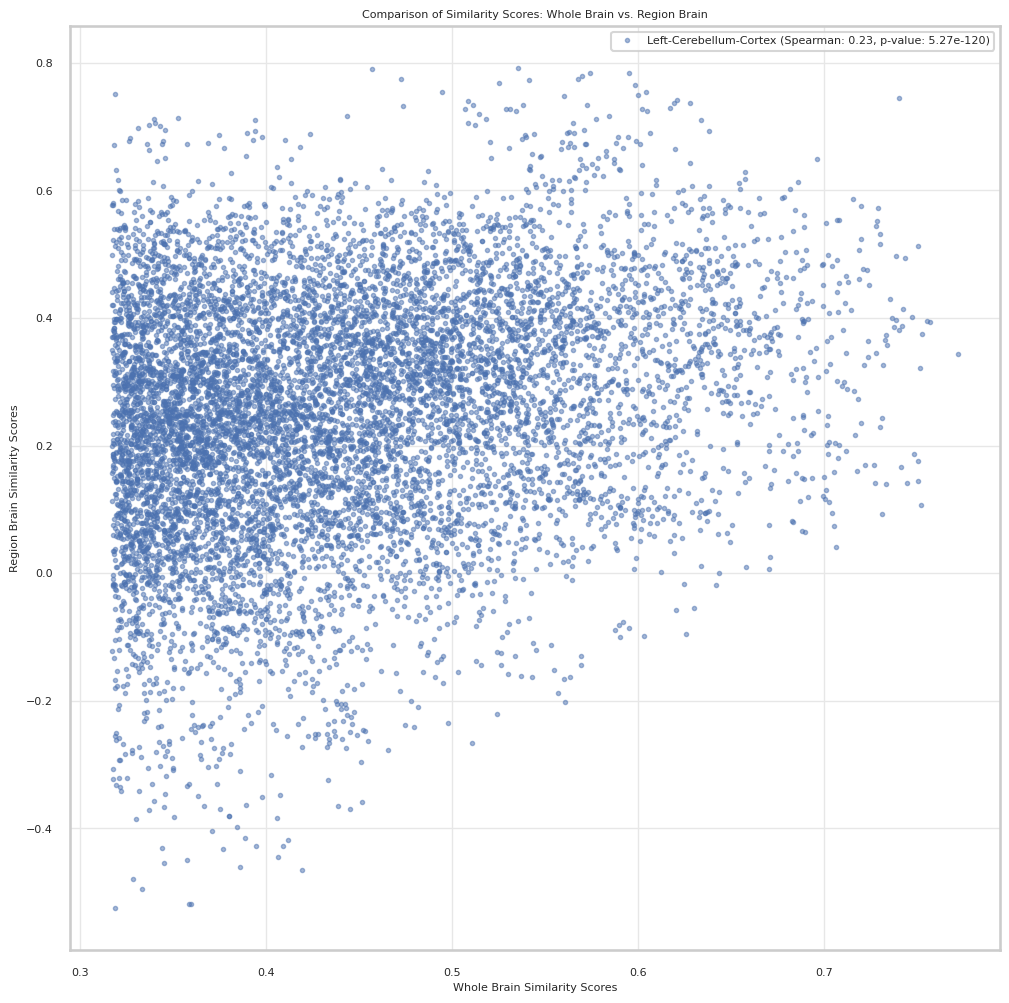

In [38]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.figure(figsize=(12, 12))

# for struct_name in struct_names:

guid_i = 1
struct_name =  struct_names[4]
top_max  = 10000
case_wb = retrieval_wb.iloc[guid_i][[f"sim{i+1}" for i in range(top_max)]].values.astype(float)
case_rb = retrieval_rb_reordered.query(f"LabelName == '{struct_name}'").iloc[guid_i][[f"sim{i+1}" for i in range(top_max)]].values.astype(float)

idx_nan = np.isnan(case_rb) + np.isnan(case_wb)
case_wb = case_wb[~idx_nan]
case_rb = case_rb[~idx_nan]

# randomly sample 10,000 points for visualization
# indices = np.random.choice(len(case_wb), size=1000, replace=False)
# case_wb = case_wb[indices]
# case_rb = case_rb[indices]

res =spearmanr(case_wb, case_rb)
corr = res.correlation
p = res.pvalue
plt.plot(case_wb, case_rb, 'o', label=f"{struct_name} (Spearman: {corr:.2f}, p-value: {p:.2e})", markersize=3, alpha=0.5)

# plt.xlim(-1, 1)
# plt.ylim(-1, 1)
plt.xlabel("Whole Brain Similarity Scores")
plt.ylabel("Region Brain Similarity Scores")
plt.title("Comparison of Similarity Scores: Whole Brain vs. Region Brain")
plt.legend()
plt.show()

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# PARAMETERS
TOP_LEVELS = [50, 200, 1000]
struct_names = retrieval_rb_reordered["LabelName"].unique()
queries = retrieval_wb["query"].unique()

# Prepare output
results = []

# Iterate over structures
for struct_name in struct_names:
    # Filter RB for this structure
    rb_struct = retrieval_rb_reordered[retrieval_rb_reordered["LabelName"] == struct_name]

    # Iterate over queries
    for query_guid in tqdm(queries, desc=f"Processing structure: {struct_name}"):
        # Get full similarity arrays (up to 1000)
        wb_sims = retrieval_wb[retrieval_wb["query"] == query_guid][[f"sim{i+1}" for i in range(max(TOP_LEVELS))]].values.astype(float).flatten()
        rb_sims = rb_struct[rb_struct["query"] == query_guid][[f"sim{i+1}" for i in range(max(TOP_LEVELS))]].values.astype(float).flatten()
        if rb_sims.size == 0:
            e = "No RB sims found"
            print(f"Error processing query {query_guid} for structure {struct_name}: {e}")
            continue
            
        # print(retrieval_wb.iloc[q_idx].query, rb_struct.iloc[q_idx].query)

        # Compute correlations for top-K
        for top_k in TOP_LEVELS:
            
            wb_top = wb_sims[:top_k]
            rb_top = rb_sims[:top_k]
            
            # remove nans
            idx_nan = np.isnan(wb_top) + np.isnan(rb_top)
            wb_top = wb_top[~idx_nan]
            rb_top = rb_top[~idx_nan]

            res = spearmanr(wb_top, rb_top)
            corr = res.correlation
            pval = res.pvalue
            
            results.append({
                "query": query_guid,
                "structure": struct_name,
                "top_k": top_k,
                "spearman_corr": corr,
                "spearman_pvalue": pval
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)



Processing structure: Left-Inf-Lat-Vent: 100%|██████████| 30/30 [00:00<00:00, 261.72it/s]
Processing structure: Left-Cerebellum-White-Matter: 100%|██████████| 30/30 [00:00<00:00, 264.41it/s]
Processing structure: Left-VentralDC: 100%|██████████| 30/30 [00:00<00:00, 262.02it/s]
Processing structure: Right-Cerebral-White-Matter: 100%|██████████| 30/30 [00:00<00:00, 264.35it/s]
Processing structure: Right-Inf-Lat-Vent: 100%|██████████| 30/30 [00:00<00:00, 263.01it/s]
Processing structure: Right-Cerebellum-White-Matter: 100%|██████████| 30/30 [00:00<00:00, 265.34it/s]
Processing structure: CC_Posterior: 100%|██████████| 30/30 [00:00<00:00, 274.55it/s]


Error processing query miriad_195_1_MR_1 for structure CC_Posterior: No RB sims found
Error processing query I451205 for structure CC_Posterior: No RB sims found
Error processing query I266800 for structure CC_Posterior: No RB sims found


Processing structure: CC_Mid_Posterior:   0%|          | 0/30 [00:00<?, ?it/s]

Error processing query miriad_195_1_MR_1 for structure CC_Mid_Posterior: No RB sims found
Error processing query I451205 for structure CC_Mid_Posterior: No RB sims found
Error processing query I266800 for structure CC_Mid_Posterior: No RB sims found


Processing structure: CC_Central:   0%|          | 0/30 [00:00<?, ?it/s]

...

Processing structure: ctx-rh-caudalanteriorcingulate: 100%|██████████| 30/30 [00:00<00:00, 269.28it/s]
Processing structure: ctx-rh-lateraloccipital: 100%|██████████| 30/30 [00:00<00:00, 268.81it/s]
Processing structure: ctx-rh-lateralorbitofrontal: 100%|██████████| 30/30 [00:00<00:00, 268.66it/s]
Processing structure: ctx-rh-precuneus: 100%|██████████| 30/30 [00:00<00:00, 268.79it/s]
Processing structure: ctx-rh-rostralanteriorcingulate: 100%|██████████| 30/30 [00:00<00:00, 268.82it/s]
Processing structure: ctx-rh-rostralmiddlefrontal: 100%|██████████| 30/30 [00:00<00:00, 266.16it/s]
Processing structure: ctx-rh-frontalpole: 100%|██████████| 30/30 [00:00<00:00, 279.82it/s]


Error processing query miriad_195_1_MR_1 for structure ctx-rh-frontalpole: No RB sims found
Error processing query I451205 for structure ctx-rh-frontalpole: No RB sims found
Error processing query I266800 for structure ctx-rh-frontalpole: No RB sims found


Processing structure: ctx-rh-temporalpole:  93%|█████████▎| 28/30 [00:00<00:00, 279.62it/s]

Error processing query miriad_195_1_MR_1 for structure ctx-rh-temporalpole: No RB sims found
Error processing query I451205 for structure ctx-rh-temporalpole: No RB sims found
Error processing query I266800 for structure ctx-rh-temporalpole: No RB sims found


Processing structure: ctx-rh-insula: 100%|██████████| 30/30 [00:00<00:00, 269.54it/s]


In [13]:
results_df

,query,structure,top_k,spearman_corr,spearman_pvalue
0,091462eb-58d5-48bb-91e2-14330a282d99,Left-Cerebral-White-Matter,50,0.222761,1.199631e-01
1,091462eb-58d5-48bb-91e2-14330a282d99,Left-Cerebral-White-Matter,200,0.320819,3.627694e-06
2,091462eb-58d5-48bb-91e2-14330a282d99,Left-Cerebral-White-Matter,1000,0.184603,4.151519e-09
3,1a81516d-c6cc-4860-9e9a-7a8b6c3af440,Left-Cerebral-White-Matter,50,-0.046146,7.503172e-01
4,1a81516d-c6cc-4860-9e9a-7a8b6c3af440,Left-Cerebral-White-Matter,200,-0.267977,1.248404e-04
...,...,...,...,...,...
9166,OAS30876_MR_d3427,ctx-rh-insula,200,0.145123,4.349071e-02
9167,OAS30876_MR_d3427,ctx-rh-insula,1000,0.017803,5.872497e-01
9168,41a10690-a3c2-4d52-9d34-134fef90bf51,ctx-rh-insula,50,0.089340,5.459372e-01
9169,41a10690-a3c2-4d52-9d34-134fef90bf51,ctx-rh-insula,200,-0.093000,1.971297e-01


In [15]:
import pandas as pd
import numpy as np

df = results_df.copy()

# Function to compute stats
def compute_stats(x):
    median = x.median()
    std = x.std()
    mean = x.mean()
    cv = std / abs(mean) if mean != 0 else np.nan
    return pd.Series({"median": median, "mean": mean, "std": std, "cv": cv})


# -----------------------------
# 1) VARIABILITY ACROSS REGIONS
# -----------------------------
# (group by query → stats across structures)
across_regions_long = (
    df.groupby(["query", "top_k"])["spearman_corr"]
      .apply(compute_stats)
      .reset_index()
)

# pivot to wide format
across_regions = (
    across_regions_long
    .pivot(index=["query", "top_k"], columns="level_2", values="spearman_corr")
    .reset_index()
)

# Now you can summarize
across_regions_summary = (
    across_regions.groupby("top_k")[["median", "std", "cv"]]
    .agg(["median", "mean", "std"])
)


# -----------------------------
# 2) VARIABILITY ACROSS SUBJECTS
# -----------------------------
# (group by structure → stats across queries)
across_subjects_long = (
    df.groupby(["structure", "top_k"])["spearman_corr"]
      .apply(compute_stats)
      .reset_index()
)

# pivot to wide format
across_subjects = (
    across_subjects_long
    .pivot(index=["structure", "top_k"], columns="level_2", values="spearman_corr")
    .reset_index()
)

# summary aggregated over all structures
across_subjects_summary = (
    across_subjects.groupby("top_k")[["median", "std", "cv"]]
    .agg(["median", "mean", "std"])
)


# -----------------------------
# 3) Filter each top_k separately
# -----------------------------
top50_regions   = across_regions[across_regions["top_k"] == 50]
top200_regions  = across_regions[across_regions["top_k"] == 200]
top1000_regions = across_regions[across_regions["top_k"] == 1000]

top50_subjects   = across_subjects[across_subjects["top_k"] == 50]
top200_subjects  = across_subjects[across_subjects["top_k"] == 200]
top1000_subjects = across_subjects[across_subjects["top_k"] == 1000]




In [53]:
top1000_subjects.sort_values(by="cv", ascending=True).query("cv < 1")

level_2,structure,top_k,cv,median,std
41,Left-Cerebral-White-Matter,1000,0.510179,0.198416,0.090791
80,Right-Cerebral-White-Matter,1000,0.541847,0.141863,0.086600
143,ctx-lh-lateralorbitofrontal,1000,0.715027,0.099181,0.066061
50,Left-Lateral-Ventricle,1000,0.718576,0.129830,0.091302
89,Right-Lateral-Ventricle,1000,0.734274,0.120909,0.082285
2,3rd-Ventricle,1000,0.742213,0.093715,0.067376
65,Right-Accumbens-area,1000,0.774973,0.097992,0.067096
11,CC_Anterior,1000,0.787280,0.080305,0.064485
125,ctx-lh-fusiform,1000,0.806813,0.067633,0.059081
26,Left-Accumbens-area,1000,0.818068,0.081330,0.077102


In [55]:
top1000_subjects["structure"].tolist()

['3rd-Ventricle',
 '4th-Ventricle',
 'Brain-Stem',
 'CC_Anterior',
 'CC_Central',
 'CC_Mid_Anterior',
 'CC_Mid_Posterior',
 'CC_Posterior',
 'Left-Accumbens-area',
 'Left-Amygdala',
 'Left-Caudate',
 'Left-Cerebellum-Cortex',
 'Left-Cerebellum-White-Matter',
 'Left-Cerebral-White-Matter',
 'Left-Hippocampus',
 'Left-Inf-Lat-Vent',
 'Left-Lateral-Ventricle',
 'Left-Pallidum',
 'Left-Putamen',
 'Left-Thalamus',
 'Left-VentralDC',
 'Right-Accumbens-area',
 'Right-Amygdala',
 'Right-Caudate',
 'Right-Cerebellum-Cortex',
 'Right-Cerebellum-White-Matter',
 'Right-Cerebral-White-Matter',
 'Right-Hippocampus',
 'Right-Inf-Lat-Vent',
 'Right-Lateral-Ventricle',
 'Right-Pallidum',
 'Right-Putamen',
 'Right-Thalamus',
 'Right-VentralDC',
 'WM-hypointensities',
 'ctx-lh-bankssts',
 'ctx-lh-caudalanteriorcingulate',
 'ctx-lh-caudalmiddlefrontal',
 'ctx-lh-cuneus',
 'ctx-lh-entorhinal',
 'ctx-lh-frontalpole',
 'ctx-lh-fusiform',
 'ctx-lh-inferiorparietal',
 'ctx-lh-inferiortemporal',
 'ctx-lh-insula

/local/tmp.5709656/ipykernel_486588/2158652892.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/local/tmp.5709656/ipykernel_486588/2158652892.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(


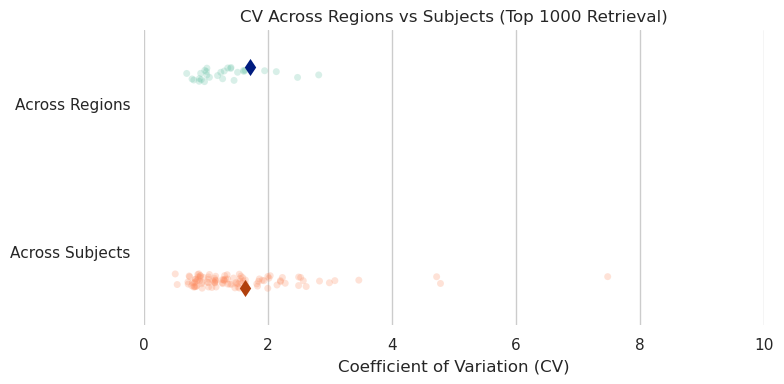

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Prepare data --------------------------------------------------------------
regions_tmp = top1000_regions[["cv"]].copy()
regions_tmp["group"] = "Across Regions"

subjects_tmp = top1000_subjects[["cv"]].copy()
subjects_tmp["group"] = "Across Subjects"

df_plot = pd.concat([regions_tmp, subjects_tmp], ignore_index=True)

# Initialize figure ---------------------------------------------------------
f, ax = plt.subplots(figsize=(8, 4))
sns.despine(bottom=True, left=True)

# Stripplot (individual points)
sns.stripplot(
    data=df_plot,
    x="cv",
    y="group",
    dodge=True,
    alpha=.25,
    zorder=1,
    palette="Set2"
)

# Pointplot (mean values)
sns.pointplot(
    data=df_plot,
    x="cv",
    y="group",
    dodge=0.5,
    palette="dark",
    errorbar=None,
    markers="d",
    markersize=6,
    linestyle="none",
)

# Legend not needed
ax.legend_.remove() if ax.get_legend() else None

# Labels
ax.set_title("CV Across Regions vs Subjects (Top 1000 Retrieval)")
ax.set_xlabel("Coefficient of Variation (CV)")
ax.set_ylabel("")
ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()


In [23]:
def prepare_df(top_df, label):
    tmp = top_df[["top_k", "cv"]].copy()
    tmp["type"] = label
    return tmp

df_regions = prepare_df(across_regions, "Across Regions")
df_subjects = prepare_df(across_subjects, "Across Subjects")

df_plot = pd.concat([df_regions, df_subjects], ignore_index=True)

# Create a combined grouping label for y-axis:
df_plot["group"] = df_plot["type"] + " – top " + df_plot["top_k"].astype(str)


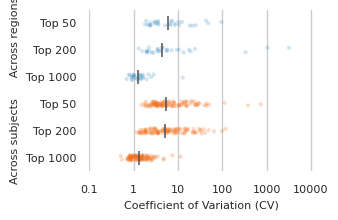

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

sns.set_theme(style="whitegrid")

# Choose base colors
base_colors = {
    "Across Regions": sns.color_palette("Blues", n_colors=4)[2],
    "Across Subjects": sns.color_palette("Oranges", n_colors=4)[2],
}

# Assign toned colors per group
def toned_color(base_color, top_k):
    # map top_k → tone
    mapping = {50: 0.3, 200: 0.6, 1000: 0.9}
    tone = mapping[top_k]
    return sns.set_hls_values(base_color, l=tone)

df_plot["color"] = df_plot.apply(
    lambda r: toned_color(base_colors[r["type"]], r["top_k"]),
    axis=1
)

# Plot -------------------------------------------------------
cm = 1/2.54 
fig, ax = plt.subplots(figsize=(9*cm, 6*cm))
sns.despine(bottom=True, left=True)

# Stripplot (individual CV values)
sns.stripplot(
    data=df_plot,
    x="cv",
    y="group",
    hue="type",               # assigns BASE color category
    palette=base_colors,      # two main colors
    dodge=False,
    alpha=.25,
    size=3,
    zorder=1,
    legend=False
)

# Pointplot (means)
sns.pointplot(
    data=df_plot,
    x="cv",
    y="group",
    estimator="median",
    color="#555555",
    dodge=False,
    errorbar=None,
    markers="|",
    markersize=10,
    linewidth=1.5,
    linestyle="none",
    log_scale=True,
    legend=False
)

# Improve legend
# sns.move_legend(
#     ax,
#     loc="lower right",
#     frameon=True,
#     title="Category"
# )

fontsize = 8
# ax.set_title("CV across Regions vs Subjects for Top-50 / 200 / 1000")
ax.set_xlabel("Coefficient of Variation (CV)", fontsize=fontsize)
ax.set_ylabel("")
ax.set_xlim(1e-1, 11000)
ax.set_xticks([1e-1, 1, 10, 100, 1000, 10000], [1e-1, 1, 10, 100, 1000, 10000], fontsize=fontsize)
ax.set_yticks(np.arange(len(df_plot["group"].unique())), 
              ["Top 50", "Top 200", "Top 1000"] * 2, fontsize=fontsize)
ax.set_ylabel("Across subjects      Across regions", fontsize=fontsize)

plt.tight_layout()
plt.show()


In [25]:
df_plot

level_2,top_k,cv,type,group,color
0,50,2.960070,Across Regions,Across Regions – top 50,"(0.13759590792838872, 0.33554987212276216, 0.4..."
1,200,24.256207,Across Regions,Across Regions – top 200,"(0.38346121057118476, 0.6473998294970162, 0.81..."
2,1000,1.403600,Across Regions,Across Regions – top 1000,"(0.8458653026427965, 0.911849957374254, 0.9541..."
3,50,3.481901,Across Regions,Across Regions – top 50,"(0.13759590792838872, 0.33554987212276216, 0.4..."
4,200,1.943387,Across Regions,Across Regions – top 200,"(0.38346121057118476, 0.6473998294970162, 0.81..."
...,...,...,...,...,...
394,200,48.604669,Across Subjects,Across Subjects – top 200,"(0.9612364243943191, 0.5228070175438597, 0.238..."
395,1000,11.453955,Across Subjects,Across Subjects – top 1000,"(0.9903091060985797, 0.880701754385965, 0.8096..."
396,50,3.474710,Across Subjects,Across Subjects – top 50,"(0.5709273182957393, 0.24210526315789477, 0.02..."
397,200,31.717225,Across Subjects,Across Subjects – top 200,"(0.9612364243943191, 0.5228070175438597, 0.238..."


In [26]:
df_plot

level_2,top_k,cv,type,group,color
0,50,2.960070,Across Regions,Across Regions – top 50,"(0.13759590792838872, 0.33554987212276216, 0.4..."
1,200,24.256207,Across Regions,Across Regions – top 200,"(0.38346121057118476, 0.6473998294970162, 0.81..."
2,1000,1.403600,Across Regions,Across Regions – top 1000,"(0.8458653026427965, 0.911849957374254, 0.9541..."
3,50,3.481901,Across Regions,Across Regions – top 50,"(0.13759590792838872, 0.33554987212276216, 0.4..."
4,200,1.943387,Across Regions,Across Regions – top 200,"(0.38346121057118476, 0.6473998294970162, 0.81..."
...,...,...,...,...,...
394,200,48.604669,Across Subjects,Across Subjects – top 200,"(0.9612364243943191, 0.5228070175438597, 0.238..."
395,1000,11.453955,Across Subjects,Across Subjects – top 1000,"(0.9903091060985797, 0.880701754385965, 0.8096..."
396,50,3.474710,Across Subjects,Across Subjects – top 50,"(0.5709273182957393, 0.24210526315789477, 0.02..."
397,200,31.717225,Across Subjects,Across Subjects – top 200,"(0.9612364243943191, 0.5228070175438597, 0.238..."


/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/venv_NeuroCBIR/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


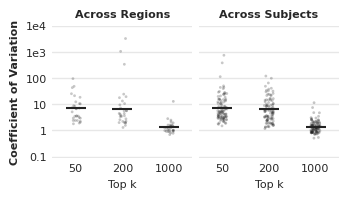

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt



# Suppose your DataFrame has these columns:
# 'group_type' = "Across Regions" or "Across Subjects"
# 'top_k' = 50, 200, 1000
# 'cv' = the coefficient of variation
# 'structure_or_query' = structure name for regions, query id for subjects

cm = 1/2.54 
desired_width_cm = 5*cm  # total width of the facet in cm
aspect = 1             # choose a width/height ratio
height = desired_width_cm / aspect  # compute height that gives desired width

sns.set_theme(style="whitegrid")
sns.set_context("talk")

# Set all font sizes to 8
plt.rcParams.update({
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 10,
    "grid.linewidth": 1,  # grid line width
    "grid.color": "#e7e7e7"
})

g = sns.catplot(
    data=df_plot,                    # your long-form DataFrame
    x="top_k",                  # top_k group on x-axis
    y="cv",                      # CV value on y-axis
    hue="top_k",                # use hue for top_k if you want color differentiation
    col="type",           # separate facet per "Across Regions" vs "Across Subjects"
    kind="strip",               # or "swarm" for nicer distribution
    palette='dark:k',
    dodge=False,
    log_scale=True,
    zorder=1,
    height=height,
    aspect=aspect,
    legend=False,
    size=2,
    alpha=0.25,
)
g.set_titles("{col_name}", fontsize=10, fontweight='bold')


# Optional: add a pointplot on top for means
for ax in g.axes.flat:
    sns.pointplot(
        data=df_plot,
        x="top_k",
        y="cv",
        color="#222222",
        dodge=False,
        markers="_",
        linestyles="",
        ax=ax,
        legend=False,
        markersize=15,
        linewidth=2,
        zorder=2,
        errorbar=None,
        
    )
    ax.set_xlabel("Top k", fontsize=8)
    ax.set_yticks([0.1, 1, 10, 100, 1000, 10000], ["0.1", "1", "10", "100", "1e3", "1e4"])
    ax.set_ylim(0.09, 10000)
    ax.tick_params(axis='both', pad=-5)  # default is ~4-5; reduce to 2 or 1

g.axes.flat[0].set_ylabel("Coefficient of Variation", fontsize=8, fontweight='bold')
g.figure.subplots_adjust(wspace=0.05, hspace=0)  # smaller values reduce space
g.figure.set_figwidth(10*cm)
g.figure.set_figheight(8*cm)

g.despine(left=True, bottom=True)

# plt.tight_layout()
plt.savefig(f"dev/figures/cv_across_top_k.pdf", format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()


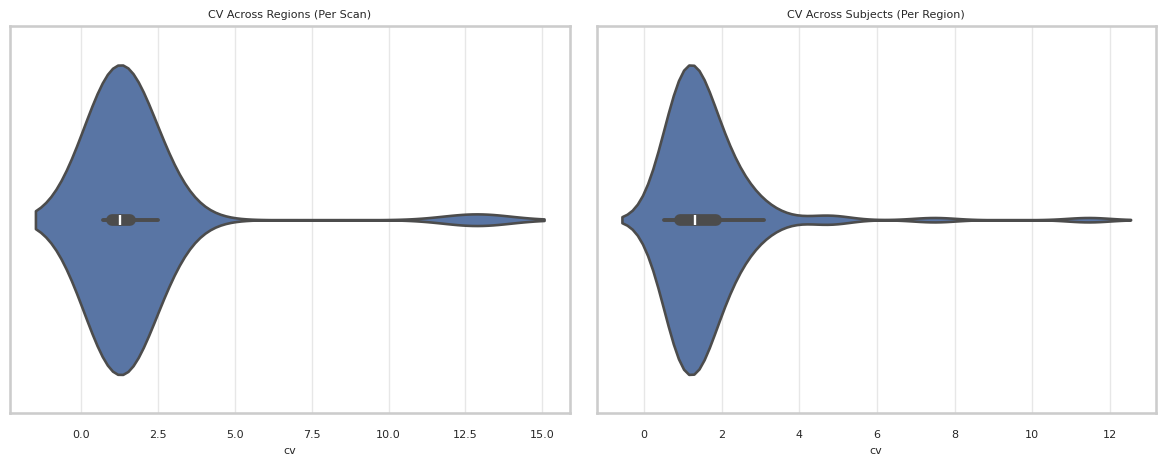

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.violinplot(data=top1000_regions, x="cv", ax=ax[0])
ax[0].set_title("CV Across Regions (Per Scan)")

sns.violinplot(data=top1000_subjects, x="cv", ax=ax[1])
ax[1].set_title("CV Across Subjects (Per Region)")

plt.tight_layout()
plt.show()


In [29]:
top1000_regions

level_2,query,top_k,cv,median,std
2,0088120a-7e5b-4880-901a-512a9d7e5644,1000,1.403600,0.053495,0.067552
5,01538383-c2e6-40f6-9ae9-37d0c52beba1,1000,1.950248,0.049964,0.087664
8,0379201c-a3c7-4d9e-9022-091fa92c3a04,1000,1.191824,0.065894,0.090387
11,091462eb-58d5-48bb-91e2-14330a282d99,1000,0.930188,0.095447,0.088449
14,09bf1e4b-e3ba-4140-913c-8e9254a4b100,1000,2.821666,0.018532,0.078577
17,0cd809b9-7c76-4794-9337-52db1a830784,1000,1.299297,0.081864,0.091602
20,0ce0d842-2fb9-4d09-959e-f90d9ec9b551,1000,12.866062,-0.015734,0.118375
23,0d84be41-e073-4a05-94d9-5e19c181d6a9,1000,1.060976,0.089059,0.087182
26,13dcdc66-4a44-4941-94af-27d9e0c00321,1000,1.615404,0.051352,0.076649
29,1a81516d-c6cc-4860-9e9a-7a8b6c3af440,1000,1.020637,0.076564,0.083438


In [35]:
combined["group"] = ["across_regions"]*len(top1000_regions) + ["across_subjects"]*len(top1000_subjects)
sns.boxplot(x="group", y="cv", data=combined)
sns.swarmplot(x="group", y="cv", data=combined, color=".25")


NameError: name 'combined' is not defined

In [32]:
# # average over queries
# averaged_results_df = results_df.groupby(["structure", "top_k"]).agg({
#     "spearman_corr": "median",
#     "spearman_pvalue": "median"
# }).reset_index()

# averaged_results_df = averaged_results_df[averaged_results_df["top_k"]==1000].sort_values(by=["spearman_corr"], ascending=[ True])
# averaged_results_df[-20:]

In [31]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_path = "/home/maia-user/cifs/Datasets/"

def plot_topk_brains(query_guid, topk, clinical_ds, retrieval_wb):
    """
    Plots axial, sagittal, coronal slices for:
    - the query brain
    - the top-k most similar retrieved brains
    """
    print(f"Plotting top-{topk} brains for query: {query_guid}")

    # --- Locate the query row from the retrieval table ---
    row = retrieval_wb[retrieval_wb["query"] == query_guid].iloc[0]
    top_ids = [row[f"top{i+1}"] for i in range(topk)]

    # --- Collect paths for query + retrieved samples ---
    all_ids = [query_guid] + top_ids
    paths = []
    for sid in all_ids:
        p = clinical_ds.loc[clinical_ds["GUID"] == sid, "brain"].values[0]
        paths.append(os.path.join(data_path, p))

    # --- Helper to load slices ---
    def load_slices(path):
        img = nib.load(path)
        vol = img.get_fdata()
        
        cx, cy, cz = np.array(vol.shape) // 2

        axial = vol[:, :, cz]
        sagittal = vol[cx, :, :]
        coronal = vol[:, cy, :]

        return axial.T, sagittal.T, coronal.T

    # Load slices
    slices = [load_slices(p) for p in paths]

    # --- Plot ---
    fig, axes = plt.subplots(3, len(paths), figsize=(3 * len(paths), 9))

    titles = ["Query"] + [f"Top {i}" for i in range(1, len(paths))]

    for col, (axial, sagittal, coronal) in enumerate(slices):
        axes[0, col].imshow(axial, cmap="gray")
        axes[0, col].set_title(titles[col])
        axes[0, col].axis("off")

        axes[1, col].imshow(sagittal, cmap="gray")
        axes[1, col].axis("off")

        axes[2, col].imshow(coronal, cmap="gray")
        axes[2, col].axis("off")

    plt.tight_layout()
    plt.show()


Plotting top-5 brains for query: 25ab084e-b6c8-4ff0-91a7-1c1af521d900


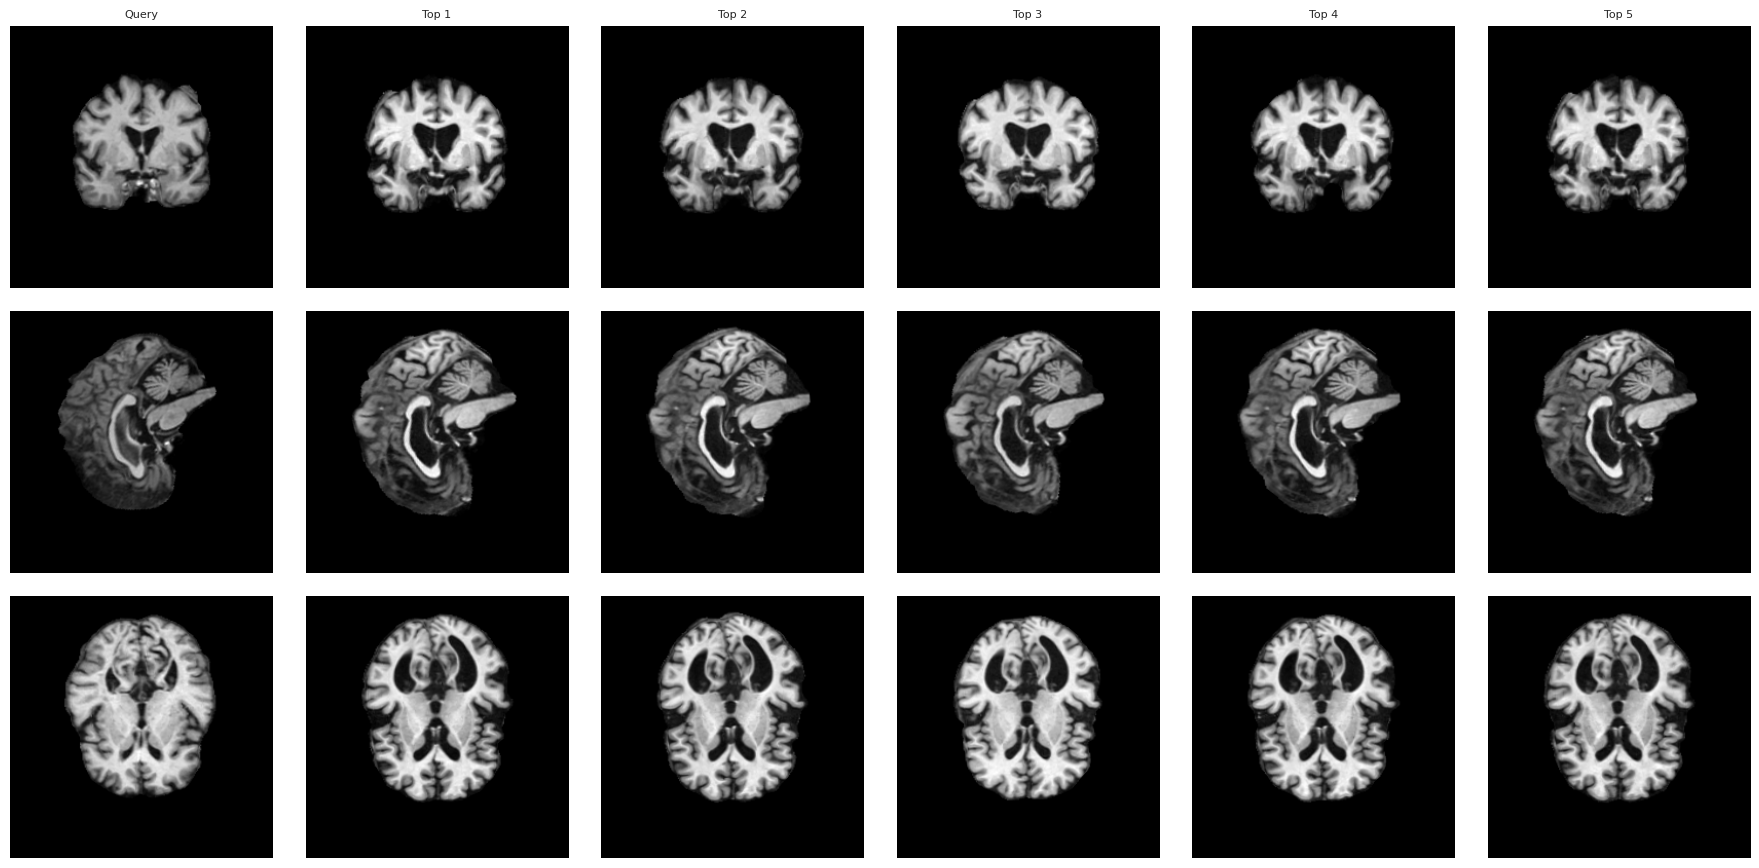

In [53]:
query_guid=retrieval_wb.iloc[6].query
plot_topk_brains(
    query_guid=query_guid,
    topk=5,
    clinical_ds=clinical_ds,
    retrieval_wb=retrieval_wb
)


In [107]:
results_df[results_df["query"] == query_guid].sort_values(by=["spearman_corr"], ascending=[ True])[-20:]

,query,structure,top_k,spearman_corr,spearman_pvalue
1750,2c509c76-f216-498f-90c7-cc60633f6029,Left-Cerebral-White-Matter,200,0.149128,5.591185e-02
11461,2c509c76-f216-498f-90c7-cc60633f6029,Left-Caudate,200,0.158101,4.254177e-02
11759,2c509c76-f216-498f-90c7-cc60633f6029,ctx-lh-lingual,1000,0.159209,8.577547e-07
3236,2c509c76-f216-498f-90c7-cc60633f6029,Left-Thalamus,1000,0.164423,3.673783e-07
1155,2c509c76-f216-498f-90c7-cc60633f6029,Left-Cerebellum-White-Matter,50,0.178612,2.701511e-01
1453,2c509c76-f216-498f-90c7-cc60633f6029,ctx-lh-postcentral,200,0.189961,1.453211e-02
1751,2c509c76-f216-498f-90c7-cc60633f6029,Left-Cerebral-White-Matter,1000,0.193187,2.091500e-09
10866,2c509c76-f216-498f-90c7-cc60633f6029,Left-Accumbens-area,50,0.194371,2.294275e-01
7927,2c509c76-f216-498f-90c7-cc60633f6029,ctx-lh-parstriangularis,200,0.194491,1.230596e-02
8521,2c509c76-f216-498f-90c7-cc60633f6029,ctx-rh-precentral,200,0.194764,1.218218e-02
